In [126]:
import datetime
import sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler,MaxAbsScaler
from sklearn.decomposition import KernelPCA
import numpy as np
import pandas as pd
import math
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.callbacks import EarlyStopping
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from keras.layers import Attention

tf.random.set_seed(666)


In [127]:
# Single step dataset preparation
def singleStepSampler(df, window):
	xRes = []
	yRes = []
	for i in range(0, len(df) - window):
		res = []
		for j in range(0, window):
			r = []
			for col in df.columns:
				r.append(df[col][i + j])
			res.append(r)
		xRes.append(res)
		yRes.append(df[['dis']].iloc[i + window].values)
	return np.array(xRes), np.array(yRes)


In [128]:
# Dataset loading
name = '3_xhl_imputMF_monthly'
csv_path = f"F:\geodata\\river_runoff_obs\\{name}.csv"
# csv_path = r"C:\Users\HP\Desktop\2_dsk_imputMF_half.csv"
usecols = ['time', 'pre', 'tm', 'tmax', 'tmin',  'dis']
dataFrame_full = pd.read_csv(csv_path, usecols=usecols)
# this refers to observed runoff and 10d_mean refers to the runoff with MA
dataFrame_full.head()

,time,pre,tm,tmax,tmin,dis
0,1962/1/31,3.184877,-13.049172,-6.414333,-18.675141,848.3
1,1962/2/28,3.144037,-6.584839,0.540288,-12.800083,764.1
2,1962/3/31,2.750418,1.196412,8.299770,-5.612987,736.4
3,1962/4/30,4.610252,7.884661,14.027556,1.927630,974.5
4,1962/5/31,11.072105,14.403047,20.308930,8.166891,2804.4


In [129]:
# Get Index of NaN Values in a Specific Column:

# Create a boolean series that identifies NaN values
is_null = dataFrame_full['dis'].isnull()


# Shift the boolean series to identify changes between NaN and non-NaN values
shifted = is_null.ne(is_null.shift()).cumsum()

# Group by the shifted series and filter to only NaN sections
nan_sections = dataFrame_full[is_null].groupby(shifted)

# Extract the start and end indices for each section and create separate lists for them
start_indices = []
end_indices = []

for _, group in nan_sections:
    start_indices.append(group.index[0])
    end_indices.append(group.index[-1])

# Create a DataFrame from the lists
null_index_df = pd.DataFrame({'Start': start_indices, 'End': end_indices})

In [130]:
null_index_df

,Start,End
0,132,136
1,141,148
2,600,647
3,694,731


In [131]:
def intercept_data(i):
	global dataFrame
	# Intercept the first section of missing value
	# dataFrame = dataFrame_full[ :null_index_df["End"][i]+365]
	dataFrame = dataFrame_full[ :null_index_df["End"][i]+1]

In [132]:
def scaler_data(dataFrame ):
	global scaler
	imputer = SimpleImputer(missing_values=np.nan) # Handling missing values
	if 'time' in dataFrame.columns:
		dataFrame.drop(columns=['time'], inplace=True)
	dataFrame = pd.DataFrame(imputer.fit_transform(dataFrame), columns=dataFrame.columns)
	dataFrame = dataFrame.reset_index(drop=True)
	# Applying feature scaling
	scaler = MinMaxScaler(feature_range=(0, 1))
	df_scaled = scaler.fit_transform(dataFrame.to_numpy())
	df_scaled = pd.DataFrame(df_scaled, columns=list(dataFrame.columns))
	target_scaler = MinMaxScaler(feature_range=(0, 1))
	df_scaled[ ['dis']] = target_scaler.fit_transform(dataFrame[ ['dis']].to_numpy())
	df_scaled = df_scaled.astype(float)
	
	return df_scaled

In [133]:
# def scaler_data(dataFrame):
#     global scaler
# 
#     # Handling missing values with SimpleImputer
#     imputer = SimpleImputer(missing_values=np.nan, strategy='mean')  
#     if 'time' in dataFrame.columns:
#         dataFrame.drop(columns=['time'], inplace=True)
# 
#     # Impute missing values
#     dataFrame = pd.DataFrame(imputer.fit_transform(dataFrame), columns=dataFrame.columns)
#     dataFrame = dataFrame.reset_index(drop=True)
# 
#     # Separate features and target (assuming 'dis' is the target)
#     features = dataFrame.drop(columns=['dis'])
#     target = dataFrame[['dis']]
# 
#     # Apply MaxAbsScaler to features
#     scaler = MaxAbsScaler()
#     features_scaled = scaler.fit_transform(features)
# 
#     # Apply MinMaxScaler to the target column ('dis')
#     target_scaler = MinMaxScaler(feature_range=(0, 1))
#     target_scaled = target_scaler.fit_transform(target)
# 
#     # Combine the scaled features and target back into a DataFrame
#     df_scaled = pd.DataFrame(features_scaled, columns=features.columns)
#     df_scaled['dis'] = target_scaled  # Add the scaled target back
# 
#     # Ensure all values are float type
#     df_scaled = df_scaled.astype(float)
# 
#     return df_scaled

In [134]:
## Data spliting

In [135]:
time_step = 24

In [136]:
def split_data(df_scaled ,i):

	# Dataset splitting
	SPLIT = 0.7 # Equal to the rate by Pr. Wang Lei train_data_rate = 0.7

	(xVal, yVal) = singleStepSampler(df_scaled, time_step)
	X_train =    xVal[:int(SPLIT * len(xVal))]
	y_train =    yVal[:int(SPLIT * len(yVal))]
	X_test =     xVal[int(SPLIT * len(xVal)):]
	y_test =     yVal[int(SPLIT * len(yVal)):]
	
	X_forecast = xVal[null_index_df["Start"][i]-time_step  :null_index_df["End"][i]+1] # For singleStepSampler, the time step need to be added.
	# X_forecast = xVal[:] # We will use the whole dataset for forecast
	yVal[null_index_df["Start"][i]-time_step  :null_index_df["End"][i]+1] = 0
	"""Whether or not as the following"""
	# X_forecast = xVal[null_index_df["Start"][i]-time_step  :null_index_df["End"][i]+1] # For singleStepSampler, the time step need to be added.

	return X_train, y_train, X_test, y_test ,X_forecast

In [137]:
# X_train, y_train, X_test, y_test , X_forecast = split_data(df_scaled,i)

In [138]:
# null_index_df["Start"][0] - null_index_df["End"][0]  

In [139]:
def model_building(X_train):
	multivariate_lstm = keras.Sequential()
	multivariate_lstm.add(keras.layers.LSTM(200, input_shape=(X_train.shape[1], X_train.shape[2])))
	multivariate_lstm.add(keras.layers.Dropout(0.4))
	multivariate_lstm.add(keras.layers.Dense(1, activation='linear')) # Only output the ET
	multivariate_lstm.compile(loss = 'MeanSquaredError', metrics=['MAE'], optimizer='Adam')
	multivariate_lstm.summary()
	return multivariate_lstm

In [140]:
# def model_building(X_train):
# 	multivariate_lstm = keras.Sequential()
# 	multivariate_lstm.add(keras.layers.LSTM(200, input_shape=(X_train.shape[1], X_train.shape[2])))
# 	multivariate_lstm.add(keras.layers.Dropout(0.4))
# 	multivariate_lstm.add(keras.layers.Dense(50, activation='linear')) # Only output the ET
# 	multivariate_lstm.compile(loss = 'MeanSquaredError', metrics=['MAE'], optimizer='Adam')
# 	multivariate_lstm.summary()
# 
# 	# Early stopping callback
# 	early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# 	return multivariate_lstm

In [141]:
# """use bidirectional LSTM"""
# from keras.layers import Bidirectional
# def model_building(X_train):
#     multivariate_lstm = keras.Sequential()
# 
#     # Add a bidirectional LSTM layer
#     multivariate_lstm.add(Bidirectional(keras.layers.LSTM(200, return_sequences=False), input_shape=(X_train.shape[1], X_train.shape[2])))
#     multivariate_lstm.add(keras.layers.Dropout(0.4))
#     multivariate_lstm.add(keras.layers.Dense(100, activation='relu'))
#     multivariate_lstm.add(keras.layers.Dense(50, activation='linear'))  # Final output
# 
#     # Compile the model
#     multivariate_lstm.compile(loss='MeanSquaredError', metrics=['MAE'], optimizer='Adam')
#     multivariate_lstm.summary()
# 
#     # Early stopping callback
#     early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#     return multivariate_lstm

In [142]:
# from keras.models import Sequential
# from keras.layers import Conv1D, MaxPooling1D, Bidirectional, LSTM, Dropout, Dense, Flatten
# from keras.optimizers import Adam
# from keras.callbacks import EarlyStopping
# from bayes_opt import BayesianOptimization
# import numpy as np
# 
# def model_building(X_train):
#     model = Sequential()
# 
#     # Add 1D Convolutional layers for feature extraction
#     model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
#     model.add(MaxPooling1D(pool_size=2))
# 
#     # Add Bi-directional LSTM layer for temporal dependencies
#     model.add(Bidirectional(LSTM(200, return_sequences=False)))
#     
#     # Dropout layer for regularization
#     model.add(Dropout(0.4))
# 
#     # Dense layers for further learning
#     model.add(Dense(100, activation='relu'))
#     model.add(Dense(50, activation='linear'))  # Output layer for runoff forecast
# 
#     # Compile the model
#     model.compile(optimizer=Adam(), loss='MeanSquaredError', metrics=['MAE'])
#     
#     # Early stopping callback
#     early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# 
#     model.summary()
#     return model
# 
# # VMD Step
# def vmd_decomposition(data):
#     # Perform Variational Mode Decomposition (VMD) here
#     # This will output multiple decomposed signals that can be used as input features
#     decomposed_modes = []  # Placeholder for decomposed signals
#     # Implement VMD decomposition here, or use a library
#     return np.array(decomposed_modes)
# 
# # Bayes Optimization for hyperparameter tuning
# def optimize_model(X_train, y_train):
#     def model_evaluate(lstm_units, dropout_rate, conv_filters):
#         model = Sequential()
# 
#         # CNN layers
#         model.add(Conv1D(filters=int(conv_filters), kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
#         model.add(MaxPooling1D(pool_size=2))
# 
#         # BiLSTM layer
#         model.add(Bidirectional(LSTM(int(lstm_units), return_sequences=False)))
#         
#         # Dropout layer
#         model.add(Dropout(dropout_rate))
# 
#         # Dense layers
#         model.add(Dense(100, activation='relu'))
#         model.add(Dense(50, activation='linear'))  # Output layer
# 
#         # Compile the model
#         model.compile(optimizer=Adam(), loss='MeanSquaredError', metrics=['MAE'])
# 
#         # Train and evaluate the model
#         model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)  # Dummy training for optimization purposes
#         
#         # Evaluation metric (can be MAE or validation loss)
#         mae = model.evaluate(X_train, y_train, verbose=0)[1]
#         return -mae  # Minimize the MAE (or other metric)
# 
#     # Define the parameter space for Bayes Optimization
#     pbounds = {
#         'lstm_units': (50, 300),
#         'dropout_rate': (0.2, 0.5),
#         'conv_filters': (32, 128)
#     }
# 
#     optimizer = BayesianOptimization(
#         f=model_evaluate,
#         pbounds=pbounds,
#         random_state=42
#     )
#     
#     optimizer.maximize(init_points=10, n_iter=50)
# 
#     best_params = optimizer.max['params']
#     return best_params
# 
# # Example usage
# # X_train and y_train should be the processed and decomposed data
# X_train_decomposed = vmd_decomposition(X_train)  # Apply VMD
# best_params = optimize_model(X_train_decomposed, y_train)  # Optimize the model with BOA
# 
# # Build the final model with best parameters found by BOA
# final_model = model_building(X_train_decomposed)


In [143]:
# def model_building(X_train):
#     multivariate_lstm = keras.Sequential()
#     # Add more layers or units to increase capacity
#     multivariate_lstm.add(keras.layers.LSTM(256, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
#     multivariate_lstm.add(keras.layers.LSTM(128))
#     multivariate_lstm.add(keras.layers.Dropout(0.4))
#     # Add additional dense layers
#     multivariate_lstm.add(keras.layers.Dense(100, activation='relu'))
#     multivariate_lstm.add(keras.layers.Dense(50, activation='linear'))  # Final output layer
#     multivariate_lstm.compile(loss='MeanSquaredError', metrics=['MAE'], optimizer='Adam')
#     multivariate_lstm.summary()
# 
#     # Early stopping callback
#     early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#     return multivariate_lstm


In [144]:
# # model source https://www.nature.com/articles/s41598-024-63989-7#Sec2
# import tensorflow as tf
# from tensorflow.keras import layers, models
# 
# def model_building(X_train):
#     multivariate_lstm = models.Sequential()
# 
#     # First LSTM layer with 512 neurons and ReLU activation
#     multivariate_lstm.add(layers.LSTM(units=512, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
# 
#     # Second LSTM layer with a progressive reduction in neurons
#     multivariate_lstm.add(layers.LSTM(units=256, return_sequences=True))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
# 
#     # Third LSTM layer with further reduction in neurons
#     multivariate_lstm.add(layers.LSTM(units=128, return_sequences=True))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
# 
#     # Fourth LSTM layer with 64 neurons
#     multivariate_lstm.add(layers.LSTM(units=64, return_sequences=True))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
# 
#     # Fifth LSTM layer with 32 neurons
#     multivariate_lstm.add(layers.LSTM(units=32, return_sequences=True))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
# 
#     # Sixth LSTM layer with 16 neurons
#     multivariate_lstm.add(layers.LSTM(units=16, return_sequences=True))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
# 
#     # Seventh LSTM layer with 8 neurons
#     multivariate_lstm.add(layers.LSTM(units=8, return_sequences=True))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
# 
#     # Eighth LSTM layer with 4 neurons
#     multivariate_lstm.add(layers.LSTM(units=4, return_sequences=False))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
# 
#     # Output layer with 1 neuron for the prediction of runoff
#     multivariate_lstm.add(layers.Dense(units=1))
# 
#     # Compile the model using Adam optimizer and MSE as loss function
#     optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
#     multivariate_lstm.compile(optimizer=optimizer, loss='mean_squared_error')
# 
#     return multivariate_lstm


In [145]:
# def model_building(X_train):
#     multivariate_lstm = keras.Sequential()
# 
#     # LSTM layer
#     multivariate_lstm.add(keras.layers.LSTM(200, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
# 
#     # Attention mechanism
#     attention = Attention()
#     multivariate_lstm.add(attention)
# 
#     multivariate_lstm.add(keras.layers.Dropout(0.4))
#     multivariate_lstm.add(keras.layers.Dense(50, activation='linear'))
# 
#     multivariate_lstm.compile(loss='MeanSquaredError', metrics=['MAE'], optimizer='Adam')
#     multivariate_lstm.summary()
# 
#     early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#     return multivariate_lstm

In [146]:
# """Add CNN Layer"""
# def model_building(X_train):
#     multivariate_lstm = keras.Sequential()
#     
#     # Add a CNN layer
#     multivariate_lstm.add(keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
#     multivariate_lstm.add(keras.layers.MaxPooling1D(pool_size=2))
#     
#     # Add LSTM layers
#     multivariate_lstm.add(keras.layers.LSTM(200, return_sequences=True))
#     multivariate_lstm.add(keras.layers.LSTM(150))
#     
#     multivariate_lstm.add(keras.layers.Dropout(0.4))
#     multivariate_lstm.add(keras.layers.Dense(250, activation='linear'))
#     
#     multivariate_lstm.compile(loss='MeanSquaredError', metrics=['MAE'], optimizer='Adam')
#     return multivariate_lstm

In [147]:
# def model_building(X_train):
#     multivariate_lstm = keras.Sequential()
#     
#     # LSTM layers with increased capacity
#     multivariate_lstm.add(keras.layers.LSTM(256, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
#     multivariate_lstm.add(keras.layers.LSTM(128))
#     
#     # Dropout for regularization
#     multivariate_lstm.add(keras.layers.Dropout(0.5))
#     
#     # Add dense layers for better learning
#     multivariate_lstm.add(keras.layers.Dense(100, activation='relu'))
#     multivariate_lstm.add(keras.layers.Dense(50, activation='linear'))  # Final output
#     
#     # Compile the model with an adjusted learning rate
#     optimizer = Adam(learning_rate=0.001)
#     multivariate_lstm.compile(loss='MeanSquaredError', metrics=['MAE'], optimizer=optimizer)
#     multivariate_lstm.summary()
#     
#     # Early stopping callback
#     early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#     
#     return multivariate_lstm

In [148]:
# # Model training
# def model_training(multivariate_lstm,X_train, y_train, X_test, y_test):
# 	history = multivariate_lstm.fit(X_train, y_train, epochs= 1000)
# 	return multivariate_lstm

In [149]:
def model_training(multivariate_lstm, X_train, y_train, X_test, y_test):
    # Define early stopping to avoid overfitting
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=50, restore_best_weights=True)

    # Train the model
    history = multivariate_lstm.fit(
        X_train, y_train, 
        epochs=1000, 
        batch_size=128, 
        validation_data=(X_test, y_test), 
        callbacks=[early_stopping],
        verbose=1  # Optional, to display training progress
    )
    
    # Return both the trained model and the training history
    return multivariate_lstm, history


In [150]:
# def medel_predict(multivariate_lstm,  X_test, y_test):
# 	global predicted_values,X_test_predicted_df
# 	
# 	dataFrame = dataFrame_full[ :null_index_df["End"][i]]# Assuming the CSV file contains a 'Date' column
# 	# dataFrame['time'] = pd.to_datetime(dataFrame['time'])
# 	dataFrame.set_index('time', inplace=True)
# 	
# 	# Forecast Plot with Dates on X-axis
# 	predicted_values = multivariate_lstm.predict(X_test)
# 	
# 	d = {		
# 		'Actual_runoff': y_test.ravel(),
# 		'Predicted_runoff': predicted_values.ravel() 
# 	}	
# 	d = pd.DataFrame(d)
# 	d.to_csv(f"F:\\geodata\\river_runoff_obs\\{name}_{time_step}_test{i}.csv")
# 	return d 

In [151]:
def medel_predict(multivariate_lstm,  X_test, y_test):
	global predicted_values,X_test_predicted_df

	dataFrame = dataFrame_full[ :null_index_df["End"][i]]# Assuming the CSV file contains a 'Date' column
	# dataFrame['time'] = pd.to_datetime(dataFrame['time'])
	dataFrame.set_index('time', inplace=True)

	# Forecast Plot with Dates on X-axis
	predicted_values = multivariate_lstm.predict(X_test)

	if len(predicted_values.shape)== 1 or predicted_values.shape[-1] == 1:
		d = {		
		'Actual_runoff': y_test.ravel(),
		'Predicted_runoff': predicted_values.ravel()
	}	
	else:
		d = {		
		'Actual_runoff': y_test.ravel(),
		'Predicted_runoff': predicted_values[:,time_step-1]
	}	
	d = pd.DataFrame(d)
	d.to_csv(f"F:\\geodata\\river_runoff_obs\\{name}_{time_step}_test{i}.csv")
	return d 

In [152]:
	# d=medel_predict(multivariate_lstm,  X_test, y_test)


In [153]:
# def forecast_model(multivariate_lstm,X_forecast):
# 	global forecast_df,forecast_values,forecast_arr
# 	forecast_values = multivariate_lstm.predict(X_forecast)
# 	# print(X_forecast[:,time_step-1,:4].shape,forecast_values[:,time_step-1].reshape(-1, 1).shape )
# 	forecast_arr = np.concatenate((X_forecast[:,time_step-1,:X_train.shape[-1] - 1],forecast_values ), axis=1)
# 	forecast_inversed = scaler.inverse_transform(forecast_arr)
# 
# 	forecast_df = pd.DataFrame(forecast_inversed, columns=usecols[1:])
# 	# forecast_df = pd.DataFrame(pd.concat([X_forecast, forecast_values], axis=1), columns=usecols[1:])
# 	dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][null_index_df["Start"][i]-time_step  :null_index_df["End"][i]+1] ###
# 	dataFrame_full.to_csv(f"F:\\geodata\\river_runoff_obs\\{name}_{time_step}_interpolated{i}.csv")
# 	forecast_df.to_csv(f"F:\\geodata\\river_runoff_obs\\{name}_{time_step}_test{i}.csv")
# 	forecast_df.plot()
# 	plt.savefig(f"F:\\geodata\\river_runoff_obs\\{name}_{time_step}_test{i}.svg")
# 	plt.show()
# 	return forecast_df
# 	


In [154]:
def forecast_model(multivariate_lstm,X_forecast):
	global forecast_df,forecast_values,forecast_arr
	forecast_values = multivariate_lstm.predict(X_forecast)
	# print(X_forecast[:,time_step-1,:X_train.shape[-1] - 1].shape,forecast_values[:,time_step-1].reshape(-1, 1).shape )
	if len(forecast_values.shape) == 1 or forecast_values.shape[-1] == 1:
		forecast_arr = np.concatenate((X_forecast[:,time_step-1,:X_train.shape[-1]-1],forecast_values[:].reshape(-1, 1) ), axis=1)
	else:
		forecast_arr = np.concatenate((X_forecast[:,time_step-1,:X_train.shape[-1]-1],forecast_values[:,time_step-1].reshape(-1, 1) ), axis=1)

	forecast_inversed = scaler.inverse_transform(forecast_arr)

	forecast_df = pd.DataFrame(forecast_inversed, columns=usecols[1:])
	# forecast_df = pd.DataFrame(pd.concat([X_forecast, forecast_values], axis=1), columns=usecols)
	dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][:len(forecast_values)] ###
	dataFrame_full.to_csv(f"F:\\geodata\\river_runoff_obs\\{name}_{time_step}_interpolated{i}.csv")
	forecast_df.to_csv(f"F:\\geodata\\river_runoff_obs\\{name}_{time_step}_forecast{i}.csv")
	forecast_df.plot()
	plt.savefig(f"F:\\geodata\\river_runoff_obs\\{name}_{time_step}_test{i}.svg")
	plt.show()
	return forecast_df
	


In [155]:
def model_evaluation(d):

	# Observed and predicted data
	observed = d['Actual_runoff']
	predicted = d['Predicted_runoff']
	
	# Correlation Coefficient (CC)
	CC = d['Predicted_runoff'].corr(d['Actual_runoff'])
	
	# Nash-Sutcliffe Efficiency (NSE)
	mean_observed = np.mean(observed)
	NSE = 1 - (np.sum((observed - predicted) ** 2) / np.sum((observed - mean_observed) ** 2))
	
	# Kling-Gupta Efficiency (KGE)
	mean_predicted = np.mean(predicted)
	std_observed = np.std(observed)
	std_predicted = np.std(predicted)
	r = np.corrcoef(observed, predicted)[0, 1]
	alpha = std_predicted / std_observed
	beta = mean_predicted / mean_observed
	KGE = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
	
	# Root-Mean-Square Error (RMSE)
	RMSE = np.sqrt(np.mean((predicted - observed) ** 2))
	
	# Mean Absolute Relative Error (MARE)
	MARE = np.mean(np.abs((observed - predicted) / mean_observed))
	
	# Percent Bias (PBIAS)
	PBIAS = 100 * np.sum(predicted - observed) / np.sum(observed)
	
	# Coefficient of Determination (R²)
	SS_res = np.sum((observed - predicted) ** 2)
	SS_tot = np.sum((observed - mean_observed) ** 2)
	R2 = 1 - (SS_res / SS_tot)
	
	# Print all metrics
	print("Correlation Coefficient (CC):", CC)
	print("Nash-Sutcliffe Efficiency (NSE):", NSE)
	print("Kling-Gupta Efficiency (KGE):", KGE)
	print("Root-Mean-Square Error (RMSE):", RMSE)
	print("Mean Absolute Relative Error (MARE):", MARE)
	print("Percent Bias (PBIAS):", PBIAS)
	print("Coefficient of Determination (R²):", R2)
	
	d.to_csv(f"F:\\geodata\\river_runoff_obs\\{name}_{time_step}_test{i}.csv")
	
	return CC,NSE,KGE,RMSE,MARE,PBIAS,R2

In [156]:
# # d=medel_predict(multivariate_lstm[0],  X_test, y_test)
# forecast_df  = forecast_model(multivariate_lstm[0],X_forecast)

In [157]:
predicted_values.shape[-1] 

1

0
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   


C:\Users\HP\AppData\Local\Temp\ipykernel_111004\1391072043.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame.drop(columns=['time'], inplace=True)


 lstm_5 (LSTM)               (None, 200)               164800    
                                                                 
 dropout_5 (Dropout)         (None, 200)               0         
                                                                 
 dense_5 (Dense)             (None, 1)                 201       
                                                                 
Total params: 165,001
Trainable params: 165,001
Non-trainable params: 0
_________________________________________________________________
Epoch 1/1000
1/1 [==============================] - 2s 2s/step - loss: 0.1470 - MAE: 0.2584 - val_loss: 0.0569 - val_MAE: 0.2021
Epoch 2/1000
1/1 [==============================] - 0s 50ms/step - loss: 0.1001 - MAE: 0.2489 - val_loss: 0.0877 - val_MAE: 0.2761
Epoch 3/1000
1/1 [==============================] - 0s 49ms/step - loss: 0.1007 - MAE: 0.2952 - val_loss: 0.0817 - val_MAE: 0.2662
Epoch 4/1000
1/1 [==============================] - 0s 50ms/step - loss: 0.

C:\Users\HP\AppData\Local\Temp\ipykernel_111004\2723745464.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][:len(forecast_values)] ###
C:\

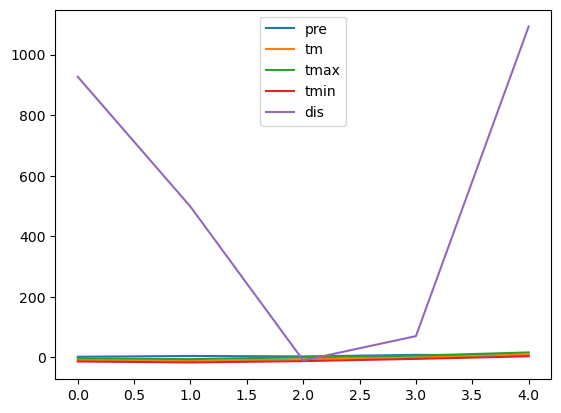

Correlation Coefficient (CC): 0.964576388557706
Nash-Sutcliffe Efficiency (NSE): 0.9026122622190248
Kling-Gupta Efficiency (KGE): 0.8261491742721785
Root-Mean-Square Error (RMSE): 0.07181738002519593
Mean Absolute Relative Error (MARE): 0.26618345978293445
Percent Bias (PBIAS): 13.83246864644894
Coefficient of Determination (R²): 0.9026122622190248
1
Model: "sequential_6"


C:\Users\HP\AppData\Local\Temp\ipykernel_111004\1391072043.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame.drop(columns=['time'], inplace=True)


_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 200)               164800    
                                                                 
 dropout_6 (Dropout)         (None, 200)               0         
                                                                 
 dense_6 (Dense)             (None, 1)                 201       
                                                                 
Total params: 165,001
Trainable params: 165,001
Non-trainable params: 0
_________________________________________________________________
Epoch 1/1000
1/1 [==============================] - 1s 1s/step - loss: 0.1408 - MAE: 0.2648 - val_loss: 0.0764 - val_MAE: 0.2201
Epoch 2/1000
1/1 [==============================] - 0s 49ms/step - loss: 0.0728 - MAE: 0.2164 - val_loss: 0.1092 - val_MAE: 0.3015
Epoch 3/1000
1/1 [==============================] - 0s 50ms/step - loss: 0

C:\Users\HP\AppData\Local\Temp\ipykernel_111004\2723745464.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][:len(forecast_values)] ###
C:\

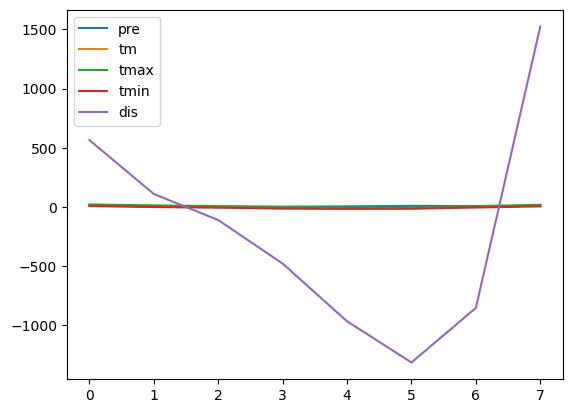

Correlation Coefficient (CC): 0.9468678969948641
Nash-Sutcliffe Efficiency (NSE): 0.8931999155101835
Kling-Gupta Efficiency (KGE): 0.8846471507211825
Root-Mean-Square Error (RMSE): 0.08907414066687994
Mean Absolute Relative Error (MARE): 0.29929811211086776
Percent Bias (PBIAS): 7.648078506250187
Coefficient of Determination (R²): 0.8931999155101835
2


C:\Users\HP\AppData\Local\Temp\ipykernel_111004\1391072043.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame.drop(columns=['time'], inplace=True)


Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_7 (LSTM)               (None, 200)               164800    
                                                                 
 dropout_7 (Dropout)         (None, 200)               0         
                                                                 
 dense_7 (Dense)             (None, 1)                 201       
                                                                 
Total params: 165,001
Trainable params: 165,001
Non-trainable params: 0
_________________________________________________________________
Epoch 1/1000
4/4 [==============================] - 1s 150ms/step - loss: 0.0737 - MAE: 0.2168 - val_loss: 0.0605 - val_MAE: 0.2267
Epoch 2/1000
4/4 [==============================] - 0s 42ms/step - loss: 0.0472 - MAE: 0.1724 - val_loss: 0.0421 - val_MAE: 0.1424
Epoch 3/1000
4/4 [==============================]

C:\Users\HP\AppData\Local\Temp\ipykernel_111004\2723745464.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][:len(forecast_values)] ###
C:\

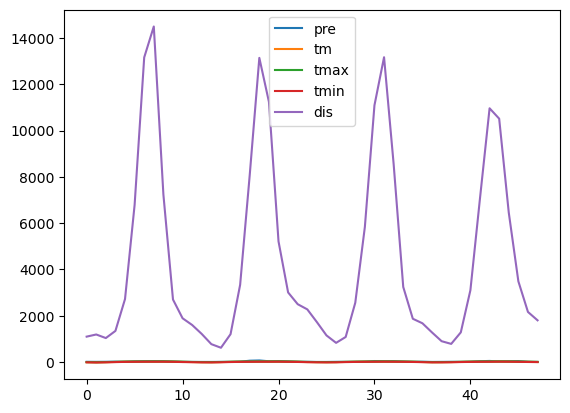

Correlation Coefficient (CC): 0.7552072174902174
Nash-Sutcliffe Efficiency (NSE): 0.5391907564355286
Kling-Gupta Efficiency (KGE): 0.6403250489076724
Root-Mean-Square Error (RMSE): 0.13865182427913755
Mean Absolute Relative Error (MARE): 0.4516266563737537
Percent Bias (PBIAS): 19.418529738793058
Coefficient of Determination (R²): 0.5391907564355286
3


C:\Users\HP\AppData\Local\Temp\ipykernel_111004\1391072043.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame.drop(columns=['time'], inplace=True)


Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_8 (LSTM)               (None, 200)               164800    
                                                                 
 dropout_8 (Dropout)         (None, 200)               0         
                                                                 
 dense_8 (Dense)             (None, 1)                 201       
                                                                 
Total params: 165,001
Trainable params: 165,001
Non-trainable params: 0
_________________________________________________________________
Epoch 1/1000
4/4 [==============================] - 1s 152ms/step - loss: 0.0583 - MAE: 0.1975 - val_loss: 0.0352 - val_MAE: 0.1644
Epoch 2/1000
4/4 [==============================] - 0s 40ms/step - loss: 0.0440 - MAE: 0.1434 - val_loss: 0.0284 - val_MAE: 0.1206
Epoch 3/1000
4/4 [==============================]

C:\Users\HP\AppData\Local\Temp\ipykernel_111004\2723745464.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][:len(forecast_values)] ###
C:\

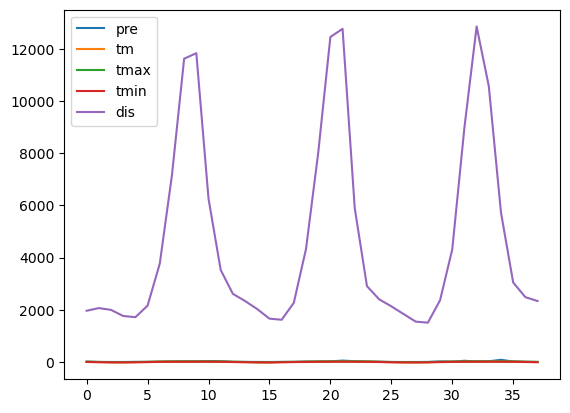

Correlation Coefficient (CC): 0.8129235963095596
Nash-Sutcliffe Efficiency (NSE): 0.5865078477488641
Kling-Gupta Efficiency (KGE): 0.6905586731050958
Root-Mean-Square Error (RMSE): 0.11483013431693305
Mean Absolute Relative Error (MARE): 0.36620990397919906
Percent Bias (PBIAS): 24.132635519051078
Coefficient of Determination (R²): 0.5865078477488641


In [158]:
for i in range(len(null_index_df)):
	print(i)
	intercept_data(i)
	df_scaled=scaler_data(dataFrame)
	X_train, y_train, X_test, y_test , X_forecast = split_data(df_scaled,i)
	multivariate_lstm = model_building(X_train)
	multivariate_lstm,history = model_training(multivariate_lstm, X_train, y_train, X_test, y_test)
	d=medel_predict(multivariate_lstm,  X_test, y_test)
	forecast_df  = forecast_model(multivariate_lstm,X_forecast)
	# d.missing_df(f"F:\geodata\\river_runoff_obs\\5_kq_imputMF{i}.csv")
	CC,NSE,KGE,RMSE,MARE,PBIAS,R2 = model_evaluation(d)
	
dataFrame_full.to_csv(f"F:\\geodata\\river_runoff_obs\\{name}_{time_step}_interpolated.csv")